### GB - Home A, B, & C

    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0   98   98   97   94  105  103  101  100  102  101  ...    120    120    123   
1  195  200  198  199  195  196  205  206  205  198  ...    206    208    209   
2  116  117  112  117  117  115  113  117  114  115  ...    494    497    498   
3  118  122  118  118  117  120  118  119  129  104  ...    104    105    101   
4  189  188  182  186  184  189  186  186  190  188  ...    204    213    209   

   M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    117    117    120    123    119    120      0  
1    207    213    213    212    213    207      1  
2    502    499    506    509    506    506      3  
3    104    103    104    101    100    104      2  
4    204    215    210    214    213    213      5  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  112  109  109  107  109  108  106  101  109  106  ...    111    108    108   
1  142  

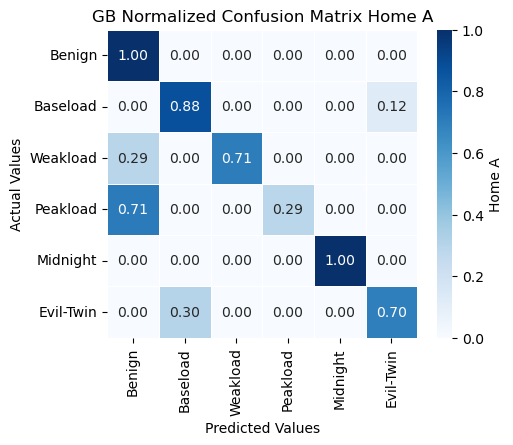

Accuracy Score: 0.8541666666666666
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       146
           1       0.74      0.88      0.81       146
           2       1.00      0.71      0.83       129
           3       1.00      0.29      0.44         7
           4       1.00      1.00      1.00       146
           5       0.85      0.70      0.77       146

    accuracy                           0.85       720
   macro avg       0.89      0.76      0.79       720
weighted avg       0.87      0.85      0.85       720

AUC Score: 0.9500647463144024


<Figure size 640x480 with 0 Axes>

In [2]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Loading datasets
# df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_test.csv")
# df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_train.csv")
df_t = pd.read_csv(r"C:\Users\olufe\projects\Appliances_Data\Power_reactive_Q\psa_data_home_A_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\Appliances_Data\Power_reactive_Q\psa_data_home_A_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']


#instantiate the model
gbModel = GradientBoostingClassifier(random_state=42)
# fit our data
gbModel.fit(X_train, y_train)

# Creating and fitting the SVC model
# svc = SVC(kernel='linear', probability=True)  # probability=True to enable predict_proba
# svc.fit(X_train, y_train)

# Use Model to get prediction
y_pred_gb = gbModel.predict(X_test)

# # Using the model to get predictions
# y_pred = svc.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_gb, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Blues', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home A'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('GB Normalized Confusion Matrix Home A')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeA_gb_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

accuracy_score(y_test, y_pred_gb)

# Accuracy score using built in scoring method
accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred_gb))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_pred_gb_prob = gbModel.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_gb_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")



In [4]:
# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_pred_gb_prob = gbModel.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_gb_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")


AUC Score: 0.9934498671942856


     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   526   481   454   450   447   438   449   450   449   441  ...   2066   
1   394   397   273   293   291   275   275   272   274   276  ...   4128   
2   681   445   457   459   459   458   454   401   402   404  ...    905   
3  3256  3378  3494  3339  3380  3435  3333  3383  3329  3455  ...   1202   
4   605   595   600   604   592   594   607   591   588   469  ...    601   

   M1432  M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0   2077   2081   2085   2085   2085   2088   2091   2087      4  
1    412    437    435    435    437    437    435    441      3  
2    997    868   2414   2651   2671   2699   2796   2781      1  
3   1225   1205   1149   1187   1156   1142   1154   1292      5  
4    744    737    732    737    730    734    681    652      1  

[5 rows x 1441 columns]
     M0    M1    M2    M3    M4    M5    M6    M7    M8    M9  ...  M1431  \
0   319   352   345   336   352  

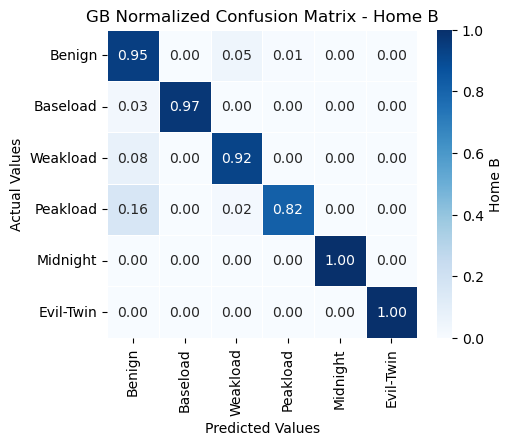

Accuracy Score: 0.9453488372093023
              precision    recall  f1-score   support

           0       0.79      0.95      0.86       146
           1       1.00      0.97      0.99       146
           2       0.93      0.92      0.93       146
           3       0.99      0.82      0.89       130
           4       1.00      1.00      1.00       146
           5       1.00      1.00      1.00       146

    accuracy                           0.95       860
   macro avg       0.95      0.94      0.95       860
weighted avg       0.95      0.95      0.95       860

AUC Score: 0.996765965255087


<Figure size 640x480 with 0 Axes>

In [5]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']


#instantiate the model
gbModel = GradientBoostingClassifier(random_state=42)
# fit our data
gbModel.fit(X_train, y_train)

# Creating and fitting the SVC model
# svc = SVC(kernel='linear', probability=True)  # probability=True to enable predict_proba
# svc.fit(X_train, y_train)

# Use Model to get prediction
y_pred_gb = gbModel.predict(X_test)

# # Using the model to get predictions
# y_pred = svc.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_gb, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Blues', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home B'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('GB Normalized Confusion Matrix - Home B')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeB_gb_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

accuracy_score(y_test, y_pred_gb)

# Accuracy score using built in scoring method
accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred_gb))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_pred_gb_prob = gbModel.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_gb_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")



    M0   M1   M2   M3   M4   M5   M6   M7   M8    M9  ...  M1431  M1432  \
0  368  366  362  361  360  358  357  238  236   234  ...    231    229   
1  629  553  553  547  554  619  565  561  553   540  ...   1065    742   
2  925  893  880  873  869  850  864  865  862  1008  ...    833    854   
3  302  316  293  327  291  277  275  224  225   223  ...    481    487   
4  519  504  488  488  488  487  486  488  490   489  ...    352    345   

   M1433  M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    234    230    228    218    229    229    228      0  
1    757    734    724    731    731    733    630      5  
2    837    840    849    725    735    724    723      5  
3    487    490    214    274    415    457    476      0  
4    341    342    338    340    341    336    335      4  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  461  459  462  465  459  316  326  328  326  328  ...    437    445    455   
1 

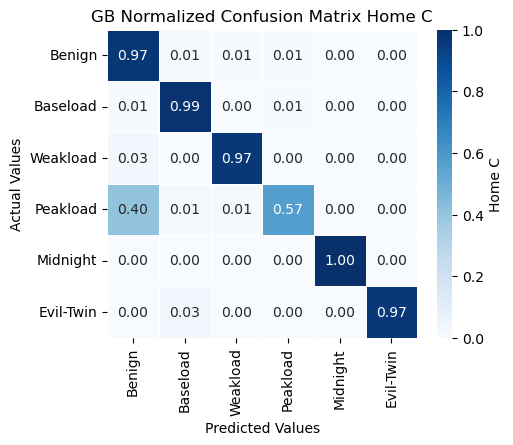

Accuracy Score: 0.9361179361179361
              precision    recall  f1-score   support

           0       0.78      0.97      0.87       146
           1       0.95      0.99      0.97       146
           2       0.99      0.97      0.98       146
           3       0.96      0.57      0.72        84
           4       1.00      1.00      1.00       146
           5       1.00      0.97      0.98       146

    accuracy                           0.94       814
   macro avg       0.95      0.91      0.92       814
weighted avg       0.94      0.94      0.93       814

AUC Score: 0.9901527994239832


<Figure size 640x480 with 0 Axes>

In [9]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Loading datasets
df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']


#instantiate the model
gbModel = GradientBoostingClassifier(random_state=42)
# fit our data
gbModel.fit(X_train, y_train)

# Creating and fitting the SVC model
# svc = SVC(kernel='linear', probability=True)  # probability=True to enable predict_proba
# svc.fit(X_train, y_train)

# Use Model to get prediction
y_pred_gb = gbModel.predict(X_test)

# Using the model to get predictions

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_gb, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Reds', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home C'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('GB Normalized Confusion Matrix Home C')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\abraham20230120\dataset_old\HomeC_gb_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

accuracy_score(y_test, y_pred_gb)

# Accuracy score using built in scoring method
accuracy_score = gbModel.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred_gb))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_pred_gb_prob = gbModel.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_gb_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")



### XGB - Home A, B, & C Dataset

    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0   98   98   97   94  105  103  101  100  102  101  ...    120    120    123   
1  195  200  198  199  195  196  205  206  205  198  ...    206    208    209   
2  116  117  112  117  117  115  113  117  114  115  ...    494    497    498   
3  118  122  118  118  117  120  118  119  129  104  ...    104    105    101   
4  189  188  182  186  184  189  186  186  190  188  ...    204    213    209   

   M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    117    117    120    123    119    120      0  
1    207    213    213    212    213    207      1  
2    502    499    506    509    506    506      3  
3    104    103    104    101    100    104      2  
4    204    215    210    214    213    213      5  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  112  109  109  107  109  108  106  101  109  106  ...    111    108    108   
1  142  

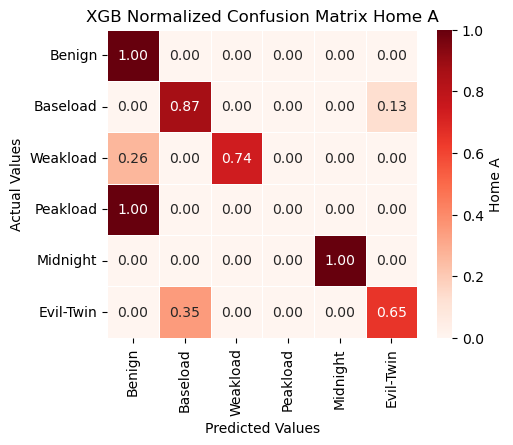

Accuracy Score: 0.8458333333333333
              precision    recall  f1-score   support

           0       0.78      1.00      0.88       146
           1       0.71      0.87      0.78       146
           2       1.00      0.74      0.85       129
           3       0.00      0.00      0.00         7
           4       1.00      1.00      1.00       146
           5       0.83      0.65      0.73       146

    accuracy                           0.85       720
   macro avg       0.72      0.71      0.71       720
weighted avg       0.85      0.85      0.84       720

AUC Score: 0.9619648687225544


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

In [4]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from xgboost import XGBClassifier

# Loading datasets
# df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_test.csv")
# df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_A_train.csv")
df_t = pd.read_csv(r"C:\Users\olufe\projects\Appliances_Data\Power_reactive_Q\psa_data_home_A_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\Appliances_Data\Power_reactive_Q\psa_data_home_A_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

#instantiate the model
xgb_model = xgb.XGBClassifier(objective="multi:softprob", random_state=0)

# fit our data
xgb_model.fit(X_train, y_train)

# Use Model to get prediction
# y_pred_gb = gbModel.predict(X_test)

y_pred_xgb = xgb_model.predict(X_test)

# Accuracy score using built in scoring method
xgb_model.score(X_test, y_test)

# Using the model to get predictions

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Reds', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home A'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('XGB Normalized Confusion Matrix Home A')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\Appliances_Data\Power_reactive_Q\HomeA_xgb_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

accuracy_score(y_test, y_pred_xgb)

# Accuracy score using built in scoring method
accuracy_score = xgb_model.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred_xgb))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_pred_xgb_prob = xgb_model.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_xgb_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")



    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  205  201  201  200  198  196  194  197  199  197  ...    215    215    214   
1  208  210  210  210  210  212  208  218  215  212  ...    217    214    213   
2  104  104  104  103  102  104  104  102  113  114  ...    114    115    118   
3  207  259  264  213  204  244  249  243  255  226  ...    220    228    223   
4  208  214  210  215  213  210  212  218  218  217  ...    206    207    204   

   M1434  M1435  M1436  M1437  M1438  M1439  Label  
0    214    215    216    215    221    217      5  
1    211    226    217    217    214    218      5  
2    118    116    115    113    111    111      4  
3    224    225    222    224    224    220      5  
4    210    211    209    205    208    204      5  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0  207  208  206  208  208  206  208  205  205  203  ...    213    212    211   
1  195  

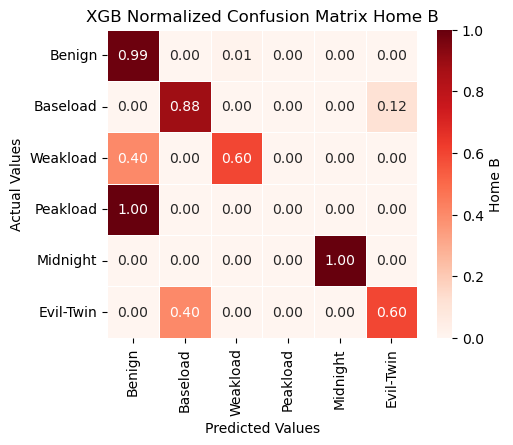

Accuracy Score: 0.8126760563380282
              precision    recall  f1-score   support

           0       0.72      0.99      0.83       146
           1       0.69      0.88      0.77       146
           2       0.97      0.60      0.74       119
           3       0.00      0.00      0.00         7
           4       1.00      1.00      1.00       146
           5       0.84      0.60      0.70       146

    accuracy                           0.81       710
   macro avg       0.70      0.68      0.67       710
weighted avg       0.83      0.81      0.80       710

AUC Score: 0.9586140966617873


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Figure size 640x480 with 0 Axes>

In [5]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from xgboost import XGBClassifier

# Loading datasets
# df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_test.csv")
# df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_B_train.csv")
df_t = pd.read_csv(r"C:\Users\olufe\projects\Appliances_Data\Power_reactive_Q\psa_data_home_B_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\Appliances_Data\Power_reactive_Q\psa_data_home_B_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

#instantiate the model
xgb_model = xgb.XGBClassifier(objective="multi:softprob", random_state=0)

# fit our data
xgb_model.fit(X_train, y_train)

# Use Model to get prediction
# y_pred_gb = gbModel.predict(X_test)

y_pred_xgb = xgb_model.predict(X_test)

# Accuracy score using built in scoring method
xgb_model.score(X_test, y_test)

# Using the model to get predictions

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Reds', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home B'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('XGB Normalized Confusion Matrix Home B')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\Appliances_Data\Power_reactive_Q\HomeB_xgb_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

accuracy_score(y_test, y_pred_xgb)

# Accuracy score using built in scoring method
accuracy_score = xgb_model.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred_xgb))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_pred_xgb_prob = xgb_model.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_xgb_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")



In [6]:
# Importing packages
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from xgboost import XGBClassifier

# Loading datasets
# df_t = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_test.csv")
# df_tr = pd.read_csv(r"C:\Users\olufe\projects\abraham20230120\dataset_old\psa_data_home_C_train.csv")
df_t = pd.read_csv(r"C:\Users\olufe\projects\Appliances_Data\Power_reactive_Q\psa_data_home_C_test.csv")
df_tr = pd.read_csv(r"C:\Users\olufe\projects\Appliances_Data\Power_reactive_Q\psa_data_home_C_train.csv")

# Displaying the first few rows of the dataframes
print(df_t.head(5))
print(df_tr.head(5))

# Checking data types
print(df_t.dtypes)
print(df_tr.dtypes)

# Preparing the training and testing data
X_train = df_tr.drop(['Label'], axis=1)
y_train = df_tr['Label']
X_test = df_t.drop(['Label'], axis=1)
y_test = df_t['Label']

#instantiate the model
xgb_model = xgb.XGBClassifier(objective="multi:softprob", random_state=0)

# fit our data
xgb_model.fit(X_train, y_train)

# Use Model to get prediction
# y_pred_gb = gbModel.predict(X_test)

y_pred_xgb = xgb_model.predict(X_test)

# Accuracy score using built in scoring method
xgb_model.score(X_test, y_test)

# Using the model to get predictions

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb, normalize="true")
cm_df = pd.DataFrame(cm)

# Plotting the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, cmap='Reds', annot=True, fmt='0.2f', linewidths=0.5,
            cbar_kws={'orientation': 'vertical', 'label': 'Home C'},
            xticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'],
            yticklabels=['Benign', 'Baseload', 'Weakload', 'Peakload', 'Midnight', 'Evil-Twin'])
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.title('XGB Normalized Confusion Matrix Home C')
plt.show()

# Saving the plot
plt.savefig(r'C:\Users\olufe\projects\Appliances_Data\Power_reactive_Q\HomeC_xgb_cm.png', bbox_inches='tight')

# Evaluating accuracy
# accuracy_score = svc.score(X_test, y_test)
# print(f"Accuracy Score: {accuracy_score}")

accuracy_score(y_test, y_pred_xgb)

# Accuracy score using built in scoring method
accuracy_score = xgb_model.score(X_test, y_test)
print(f"Accuracy Score: {accuracy_score}")

# Classification report
print(classification_report(y_test, y_pred_xgb))

# AUC score calculation
# For multi-class, use one-vs-rest approach
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_binarized.shape[1]

# y_pred_prob = svc.predict_proba(X_test)
# Use Model to get prediction
y_pred_xgb_prob = xgb_model.predict_proba(X_test)

# Compute the AUC score
auc_score = roc_auc_score(y_test_binarized, y_pred_xgb_prob, multi_class='ovr')
print(f"AUC Score: {auc_score}")



    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0   80   76   78   76   76   73   73   73   72   75  ...     74     75     73   
1   74   74   74   73   76   74   93   74   78   73  ...     72     70     75   
2  171  171  168  165  170  168  168  163  167  171  ...    163    162    159   
3   78   85   82   83   82   82   82   88   82   80  ...    103     99     98   
4   78   85   82   83   82   82   82   88   82   80  ...    103     99     98   

   M1434  M1435  M1436  M1437  M1438  M1439  Label  
0     74     72     75     74     84     81      0  
1     78     76     75     73     73     73      0  
2    170    171    168    160    167    170      5  
3     98     97     98     97     97     97      4  
4     98     97     98     97     97     97      2  

[5 rows x 1441 columns]
    M0   M1   M2   M3   M4   M5   M6   M7   M8   M9  ...  M1431  M1432  M1433  \
0   86   85   85   83   85   83   85   83   86   84  ...     86     84     86   
1  104  

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4], got [0 1 2 4 5]